In [ ]:
!pip -q install plotly ordpy librosa soundfile shap

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import librosa
import librosa.display
import shap
import ordpy

from itertools import product
from joblib import Parallel, delayed
from scipy.io import arff
from scipy.signal import stft

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = "/content/drive/MyDrive/training.zip"
!unzip "$zip_path" -d /content/heart_data

Archive:  /content/drive/MyDrive/training.zip
replace /content/heart_data/training-a/a0307.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!find /content/heart_data -maxdepth 1 -type d

/content/heart_data
/content/heart_data/training-d
/content/heart_data/training-f
/content/heart_data/training-c
/content/heart_data/training-b
/content/heart_data/training-e
/content/heart_data/training-a


In [ ]:
sample_hea = df.loc[0, "hea_path"]

with open(sample_hea, "r") as f:
    print(f.read())

d0009 1 2000 24811
d0009.wav 16+44 1 16 0 0 0 0 PCG
# Abnormal



In [ ]:
root = "/content/heart_data"
rows = []

for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)

    if not os.path.isdir(folder_path):
        continue

    for file_name in os.listdir(folder_path):
        if not file_name.endswith(".hea"):
            continue

        record_id = os.path.splitext(file_name)[0]
        hea_path = os.path.join(folder_path, file_name)
        wav_path = os.path.join(folder_path, record_id + ".wav")

        label = None
        with open(hea_path, "r") as f:
            for line in f:
                line = line.strip()
                if line.startswith("#"):
                    label = line[1:].strip()
                    break

        rows.append({
            "record_id": record_id,
            "subset": folder,
            "wav_path": wav_path if os.path.exists(wav_path) else None,
            "hea_path": hea_path,
            "label": label
        })

df = pd.DataFrame(rows)
df.head()

,record_id,subset,wav_path,hea_path,label
0,d0009,training-d,/content/heart_data/training-d/d0009.wav,/content/heart_data/training-d/d0009.hea,Abnormal
1,d0032,training-d,/content/heart_data/training-d/d0032.wav,/content/heart_data/training-d/d0032.hea,Abnormal
2,d0050,training-d,/content/heart_data/training-d/d0050.wav,/content/heart_data/training-d/d0050.hea,Normal
3,d0046,training-d,/content/heart_data/training-d/d0046.wav,/content/heart_data/training-d/d0046.hea,Abnormal
4,d0015,training-d,/content/heart_data/training-d/d0015.wav,/content/heart_data/training-d/d0015.hea,Normal


In [ ]:
print("Total number of records:", len(df))
print(df["label"].value_counts(dropna=False))

Total number of records: 3240
label
Normal      2575
Abnormal     665
Name: count, dtype: int64


In [ ]:
df["label"] = df["label"].str.strip()
df["target"] = df["label"].map({"Normal": 0, "Abnormal": 1})

In [ ]:
print(df["label"].value_counts())
print(df["target"].value_counts())

label
Normal      2575
Abnormal     665
Name: count, dtype: int64
target
0    2575
1     665
Name: count, dtype: int64


In [ ]:
import librosa
import numpy as np

signals = []
targets = []
record_ids = []

for _, row in df.iterrows():
    y, sr = librosa.load(row["wav_path"], sr=None)
    signals.append(y.astype(np.float32))
    targets.append(int(row["target"]))
    record_ids.append(row["record_id"])

y_train = np.array(targets, dtype=int)

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(signals))

# 70% train, 15% val, 15% test
idx_train, idx_temp = train_test_split(
    idx, test_size=0.3, random_state=42, stratify=y_train
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.5, random_state=42, stratify=y_train[idx_temp]
)

signals_train = [signals[i] for i in idx_train]
signals_val   = [signals[i] for i in idx_val]
signals_test  = [signals[i] for i in idx_test]

y_train_split = y_train[idx_train]
y_val_split   = y_train[idx_val]
y_test_split  = y_train[idx_test]

print(f"Train: {len(signals_train)}, Val: {len(signals_val)}, Test: {len(signals_test)}")

Train: 2268, Val: 486, Test: 486


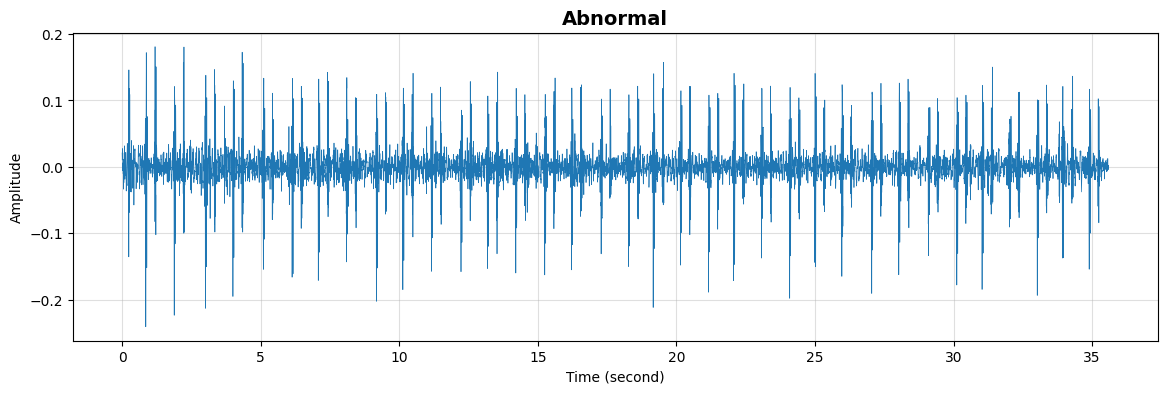

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

idx = 0
t = np.arange(len(signals_train[idx])) / 2000

plt.figure(figsize=(14, 4))
plt.plot(t, signals_train[idx], color='#1f77b4', lw=0.5)
plt.title(f"{'Normal' if y_train_split[idx] == 0 else 'Abnormal'}",
          fontsize=14, fontweight='bold')
plt.xlabel("Time (second)")
plt.ylabel("Amplitude")
plt.grid(True, ls='-', alpha=0.4)
plt.show()

In [ ]:
m_values   = [4, 5, 6, 7]
tau_values = [1, 2, 3, 4]

def compute_hc(ts, m, tau):
    return ordpy.complexity_entropy(ts, dx=m, dy=1, taux=tau)


random.seed(42)
idx_sample = random.sample(range(len(signals_train)), min(300, len(signals_train)))
signals_sample = [signals_train[i] for i in idx_sample]
y_sample = y_train_split[idx_sample]

scores = {}

for m, tau in product(m_values, tau_values):
    HC_sample = np.array(
        Parallel(n_jobs=-1)(delayed(compute_hc)(ts, m, tau) for ts in signals_sample),
        dtype=float
    )
    HC_val = np.array(
        Parallel(n_jobs=-1)(delayed(compute_hc)(ts, m, tau) for ts in signals_val),
        dtype=float
    )

    mask_tr = np.isfinite(HC_sample).all(axis=1)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(HC_sample[mask_tr], y_sample[mask_tr])

    mask_val = np.isfinite(HC_val).all(axis=1)
    auc = roc_auc_score(y_val_split[mask_val], clf.predict_proba(HC_val[mask_val])[:, 1])
    scores[(m, tau)] = auc
    print(f"m={m}, tau={tau} → Val AUC = {auc:.3f}")

top3 = sorted(scores, key=scores.get, reverse=True)[:3]
best_params = top3[0]
print(f"\nТоп-3: {top3}")
print(f"Лучшая пара: m={best_params[0]}, τ={best_params[1]}")

KeyboardInterrupt: 

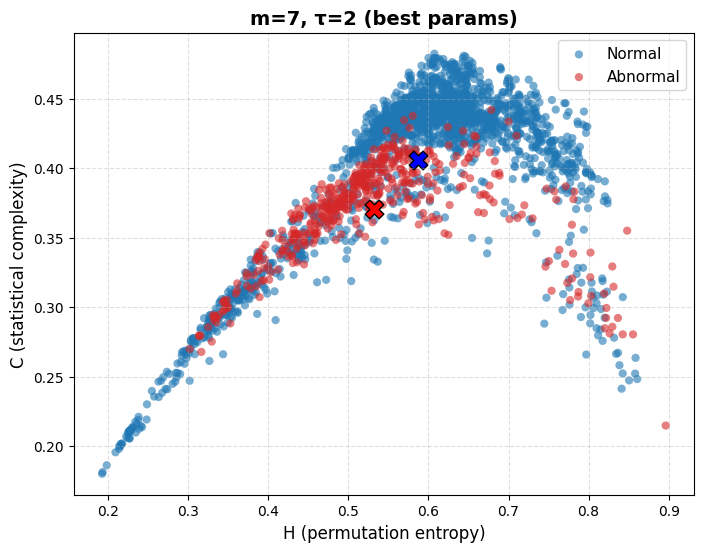

In [ ]:
m_best, tau_best = best_params


HC_train_best = np.array(
    Parallel(n_jobs=-1)(delayed(compute_hc)(ts, m_best, tau_best) for ts in signals_train),
    dtype=float
)

mask = np.isfinite(HC_train_best).all(axis=1)
HC_clean, y_clean = HC_train_best[mask], y_train_split[mask]

fig, ax = plt.subplots(figsize=(8, 6))

for cls, color, label in zip([0, 1], ['#1f77b4', '#d62728'], ['Normal', 'Abnormal']):
    mk = (y_clean == cls)
    ax.scatter(HC_clean[mk, 0], HC_clean[mk, 1],
               c=color, label=label, s=35, alpha=0.6, edgecolors='none')

c0 = HC_clean[y_clean == 0].mean(axis=0)
c1 = HC_clean[y_clean == 1].mean(axis=0)
ax.scatter(*c0, c='blue', marker='X', s=180, edgecolors='k')
ax.scatter(*c1, c='red', marker='X', s=180, edgecolors='k')

ax.set_title(f"m={m_best}, τ={tau_best} (best params)", fontsize=14, fontweight='bold')
ax.set_xlabel("H (permutation entropy)", fontsize=12)
ax.set_ylabel("C (statistical complexity)", fontsize=12)
ax.grid(True, ls='--', alpha=0.4)
ax.legend(fontsize=11)
plt.show()

In [ ]:
def hurst_RS(series, min_window=50, max_window=None, simplified=True):
    x = np.asarray(series, dtype=float)
    if np.isnan(x).any():
        return np.nan

    incs = x[1:] - x[:-1]
    if len(incs) < 200:
        return np.nan

    def RS_simpl(incs_window):
        if incs_window.size < 2:
            return 0.0
        level = np.hstack([[0.0], np.cumsum(incs_window)])
        R = np.max(level) - np.min(level)
        S = np.std(incs_window, ddof=1)
        if R == 0 or S == 0 or np.isnan(S):
            return 0.0
        return R / S

    def RS_full(incs_window):
        if incs_window.size < 2:
            return 0.0
        mean_inc = np.mean(incs_window)
        dev = incs_window - mean_inc
        Z = np.cumsum(dev)
        R = np.max(Z) - np.min(Z)
        S = np.std(incs_window, ddof=1)
        if R == 0 or S == 0 or np.isnan(S):
            return 0.0
        return R / S

    RS_func = RS_simpl if simplified else RS_full

    N = len(incs)
    max_window = max_window or (N - 1)
    if max_window < min_window:
        return np.nan

    ws = [int(10**p) for p in np.arange(np.log10(min_window), np.log10(max_window), 0.25)]
    ws = sorted(set([w for w in ws if w >= min_window and w <= max_window]))
    if len(ws) < 5:
        return np.nan

    RS_vals = []
    ws_used = []
    for w in ws:
        rs_list = []
        for start in range(0, N, w):
            if start + w > N:
                break
            v = RS_func(incs[start:start+w])
            if v != 0:
                rs_list.append(v)
        if len(rs_list) > 0:
            ws_used.append(w)
            RS_vals.append(np.mean(rs_list))

    if len(ws_used) < 5:
        return np.nan

    xlog = np.log10(np.array(ws_used, dtype=float))
    ylog = np.log10(np.array(RS_vals, dtype=float))
    A = np.vstack([xlog, np.ones_like(xlog)]).T
    H, b = np.linalg.lstsq(A, ylog, rcond=None)[0]
    return float(H)

def compute_hurst_all(X, min_window=50, simplified=True):
    Hh = np.empty(X.shape[0], dtype=float)
    for i in range(X.shape[0]):
        Hh[i] = hurst_RS(X[i], min_window=min_window, simplified=simplified)
    return Hh

In [ ]:
Hperm = HC_train_best[:, 0]
C = HC_train_best[:, 1]

Hh = np.array(
    Parallel(n_jobs=-1)(
        delayed(hurst_RS)(s, min_window=50, simplified=True) for s in signals_train
    )
)

y_plot = np.where(y_train_split == 1, "Abnormal", "Normal")

mask = np.isfinite(Hperm) & np.isfinite(C) & np.isfinite(Hh)
print("Valid points for plot:", int(mask.sum()))

df3 = pd.DataFrame({
    "Hperm": Hperm[mask],
    "C": C[mask],
    "Hh": Hh[mask],
    "target": y_plot[mask]
})

fig = px.scatter_3d(
    df3, x="Hperm", y="C", z="Hh",
    color="target", opacity=0.8,
    color_discrete_map={"Normal": "#1f77b4", "Abnormal": "#d62728"},
    hover_data=["Hperm", "C", "Hh"]
)

fig.update_layout(
    scene=dict(
        xaxis_title="Permutation entropy H",
        yaxis_title="Complexity C",
        zaxis_title="Hurst exponent Hh"
    ),
    margin=dict(l=0, r=0, b=0, t=60),
    title=f"3D: ordpy(H,C) + Hurst | m={m_best}, τ={tau_best}"
)

fig.show()

Valid points for plot: 2268


In [ ]:
X_ordpy_train = np.column_stack([Hperm, C, Hh])
mask_train = np.isfinite(X_ordpy_train).all(axis=1)


HC_test = np.array(
    Parallel(n_jobs=-1)(delayed(compute_hc)(ts, m_best, tau_best) for ts in signals_test),
    dtype=float
)
Hh_test = np.array(
    Parallel(n_jobs=-1)(
        delayed(hurst_RS)(s, min_window=50, simplified=True) for s in signals_test
    )
)
X_ordpy_test = np.column_stack([HC_test[:, 0], HC_test[:, 1], Hh_test])
mask_test = np.isfinite(X_ordpy_test).all(axis=1)


scaler = StandardScaler()
X_tr = scaler.fit_transform(X_ordpy_train[mask_train])
X_te = scaler.transform(X_ordpy_test[mask_test])

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train_split[mask_train])

y_pred = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]

print(f"ordpy(H,C) + Hurst | m={m_best}, τ={tau_best}")
print(f"Test AUC: {roc_auc_score(y_test_split[mask_test], y_proba):.3f}\n")
print(classification_report(y_test_split[mask_test], y_pred,
                            target_names=['Normal', 'Abnormal']))

ordpy(H,C) + Hurst | m=7, τ=2
Test AUC: 0.795

              precision    recall  f1-score   support

      Normal       0.79      0.97      0.87       387
    Abnormal       0.08      0.01      0.02        99

    accuracy                           0.77       486
   macro avg       0.43      0.49      0.44       486
weighted avg       0.65      0.77      0.70       486



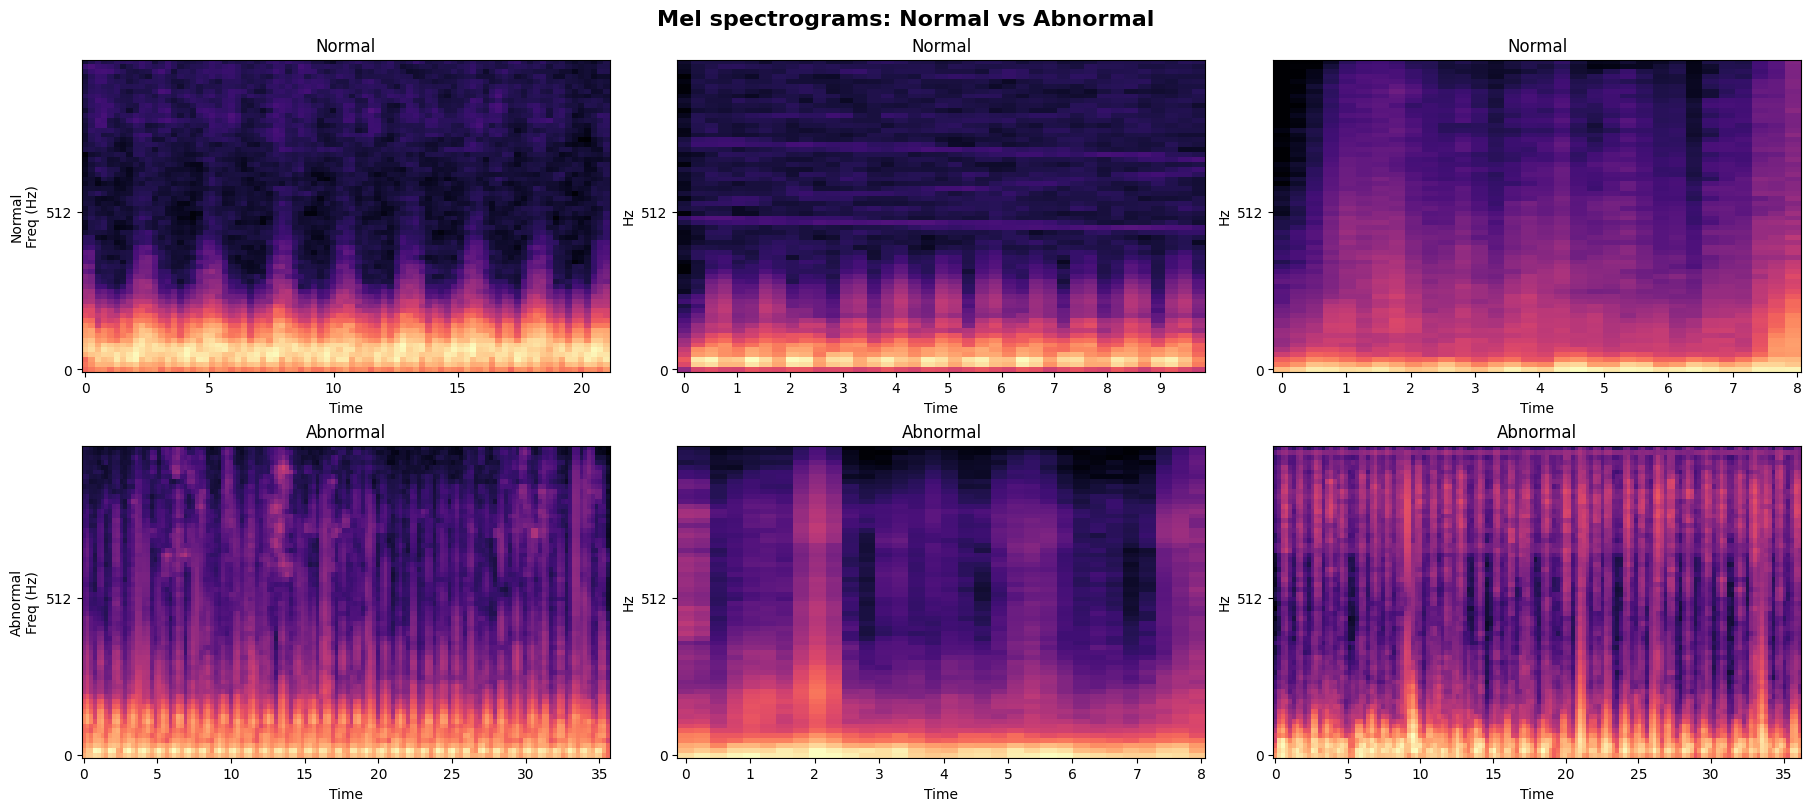

In [ ]:
idx_normal = np.where(y_train_split == 0)[0][:3]
idx_abnormal = np.where(y_train_split == 1)[0][:3]

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)

for j, idx in enumerate(idx_normal):
    S = librosa.feature.melspectrogram(y=signals_train[idx], sr=2000, n_mels=64, fmax=1000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=2000, x_axis='time', y_axis='mel',
                             ax=axes[0, j], fmax=1000)
    axes[0, j].set_title(f"Normal")

for j, idx in enumerate(idx_abnormal):
    S = librosa.feature.melspectrogram(y=signals_train[idx], sr=2000, n_mels=64, fmax=1000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=2000, x_axis='time', y_axis='mel',
                             ax=axes[1, j], fmax=1000)
    axes[1, j].set_title(f"Abnormal")

axes[0, 0].set_ylabel("Normal\nFreq (Hz)")
axes[1, 0].set_ylabel("Abnormal\nFreq (Hz)")
plt.suptitle("Mel spectrograms: Normal vs Abnormal", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
def extract_mfcc(signal, sr=2000, n_mfcc=20):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc, n_mels=64, fmax=1000)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

X_mfcc_train = np.array([extract_mfcc(s) for s in signals_train])
X_mfcc_test  = np.array([extract_mfcc(s) for s in signals_test])

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_mfcc_train)
X_te = scaler.transform(X_mfcc_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train_split)

y_pred = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]

print(f"MFCC (40 features)")
print(f"Test AUC: {roc_auc_score(y_test_split, y_proba):.3f}\n")
print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

MFCC (40 features)
Test AUC: 0.899

              precision    recall  f1-score   support

      Normal       0.87      0.97      0.92       387
    Abnormal       0.77      0.44      0.56        99

    accuracy                           0.86       486
   macro avg       0.82      0.71      0.74       486
weighted avg       0.85      0.86      0.84       486



In [ ]:
def extract_audio_features(signal, sr=2000):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20, n_mels=64, fmax=1000)
    delta = librosa.feature.delta(mfcc)
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y=signal)

    return np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        centroid.mean(axis=1), centroid.std(axis=1),
        bandwidth.mean(axis=1), bandwidth.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
    ])

X_full_train = np.array([extract_audio_features(s) for s in signals_train])
X_full_test  = np.array([extract_audio_features(s) for s in signals_test])

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_full_train)
X_te = scaler.transform(X_full_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train_split)

y_pred = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]

print(f"MFCC + Delta + Spectral (88 features)")
print(f"Test AUC: {roc_auc_score(y_test_split, y_proba):.3f}\n")
print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

MFCC + Delta + Spectral (88 features)
Test AUC: 0.900

              precision    recall  f1-score   support

      Normal       0.90      0.96      0.93       387
    Abnormal       0.79      0.57      0.66        99

    accuracy                           0.88       486
   macro avg       0.84      0.76      0.79       486
weighted avg       0.87      0.88      0.87       486



In [ ]:
def extract_tfd_svd(signal, sr=2000, nperseg=240, noverlap=80, n_svd=20):
    _, _, Zxx = stft(signal, fs=sr, nperseg=nperseg, noverlap=noverlap)
    S = np.abs(Zxx)
    U, s, Vt = np.linalg.svd(S, full_matrices=False)
    return np.concatenate([
        s[:n_svd],
        U[:, :n_svd].mean(axis=0),
        U[:, :n_svd].std(axis=0),
        Vt[:n_svd, :].mean(axis=1),
        Vt[:n_svd, :].std(axis=1),
    ])

X_tfd_train = np.array([extract_tfd_svd(s) for s in signals_train])
X_tfd_test  = np.array([extract_tfd_svd(s) for s in signals_test])

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tfd_train)
X_te = scaler.transform(X_tfd_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train_split)

y_pred = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]

print(f"TFD-SVD (100 features)")
print(f"Test AUC: {roc_auc_score(y_test_split, y_proba):.3f}\n")
print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

TFD-SVD (100 features)
Test AUC: 0.839

              precision    recall  f1-score   support

      Normal       0.89      0.96      0.92       387
    Abnormal       0.75      0.53      0.62        99

    accuracy                           0.87       486
   macro avg       0.82      0.74      0.77       486
weighted avg       0.86      0.87      0.86       486



In [ ]:
X_combined_train = np.hstack([X_full_train, X_tfd_train])
X_combined_test  = np.hstack([X_full_test, X_tfd_test])

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_combined_train)
X_te = scaler.transform(X_combined_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train_split)

y_pred = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]

print(f"MFCC + Delta + Spectral + TFD-SVD (188 features)")
print(f"Test AUC: {roc_auc_score(y_test_split, y_proba):.3f}\n")
print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

MFCC + Delta + Spectral + TFD-SVD (188 features)
Test AUC: 0.911

              precision    recall  f1-score   support

      Normal       0.90      0.95      0.92       387
    Abnormal       0.75      0.59      0.66        99

    accuracy                           0.88       486
   macro avg       0.83      0.77      0.79       486
weighted avg       0.87      0.88      0.87       486



In [ ]:
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_combined_train)
X_te = scaler.transform(X_combined_test)

models = {
    'Logistic regression': LogisticRegression(C=1, max_iter=1000),
    'Random Forest':           RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':       GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM':                     SVC(kernel='rbf', probability=True, random_state=42),
}

for name, model in models.items():
    model.fit(X_tr, y_train_split)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test_split, y_proba)


    print(f"{name}")
    print(f"Test AUC: {auc:.3f}")
    print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

Logistic regression
Test AUC: 0.911
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.92       387
    Abnormal       0.75      0.59      0.66        99

    accuracy                           0.88       486
   macro avg       0.83      0.77      0.79       486
weighted avg       0.87      0.88      0.87       486

Random Forest
Test AUC: 0.967
              precision    recall  f1-score   support

      Normal       0.90      0.97      0.94       387
    Abnormal       0.84      0.59      0.69        99

    accuracy                           0.89       486
   macro avg       0.87      0.78      0.81       486
weighted avg       0.89      0.89      0.89       486

Gradient Boosting
Test AUC: 0.962
              precision    recall  f1-score   support

      Normal       0.92      0.96      0.94       387
    Abnormal       0.83      0.69      0.75        99

    accuracy                           0.91       486
   macro avg       0.88     

In [ ]:
best_model = models['Gradient Boosting']
y_pred = best_model.predict(X_te)
y_proba = best_model.predict_proba(X_te)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test_split, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Results:")
print(f"ROC-AUC: {roc_auc_score(y_test_split, y_proba):.3f}")
print(f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"Recall: {sensitivity:.3f}  ({tp} out of {tp+fn} patient were found)")
print(f"Specificity: {specificity:.3f}  ({tn} out of {tn+fp} healthy people were found)")
print(f"Precision: {tp/(tp+fp):.3f}")
print(f"F1 (Abnormal):{2*tp/(2*tp+fp+fn):.3f}")

Results:
ROC-AUC: 0.962
Accuracy: 0.907
Recall: 0.687  (68 out of 99 patient were found)
Specificity: 0.964  (373 out of 387 healthy people were found)
Precision: 0.829
F1 (Abnormal):0.751


In [ ]:
gbm_weighted = GradientBoostingClassifier(n_estimators=200, random_state=42)
gbm_weighted.fit(X_tr, y_train_split,
                 sample_weight=np.where(y_train_split == 1, 3, 1))

y_pred = gbm_weighted.predict(X_te)
y_proba = gbm_weighted.predict_proba(X_te)[:, 1]

print(f"GBM with weights — Test AUC: {roc_auc_score(y_test_split, y_proba):.3f}\n")
print(classification_report(y_test_split, y_pred, target_names=['Normal', 'Abnormal']))

GBM with weights — Test AUC: 0.963

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94       387
    Abnormal       0.79      0.76      0.77        99

    accuracy                           0.91       486
   macro avg       0.86      0.85      0.86       486
weighted avg       0.91      0.91      0.91       486



In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test_split, y_pred).ravel()

print("Results:")
print(f"ROC-AUC:{roc_auc_score(y_test_split, y_proba):.3f}")
print(f"Accuracy:{(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"Recall:{tp/(tp+fn):.3f}  ({tp} out of {tp+fn} patient were found)")
print(f"Specificity:{tn/(tn+fp):.3f}  ({tn} out of {tn+fp} healthy people were found)")
print(f"Precision:{tp/(tp+fp):.3f}")
print(f"F1 (Abnormal):{2*tp/(2*tp+fp+fn):.3f}")


Results:
ROC-AUC:0.963
Accuracy:0.909
Recall:0.758  (75 out of 99 patient were found)
Specificity:0.948  (367 out of 387 healthy people were found)
Precision:0.789
F1 (Abnormal):0.773


In [ ]:
real_auc = roc_auc_score(y_test_split, y_proba)

fake_aucs = []
for _ in range(200):
    y_shuffled = np.random.permutation(y_test_split)
    fake_aucs.append(roc_auc_score(y_shuffled, y_proba))

print(f"Actual AUC:{real_auc:.3f}")
print(f"Random AUC (mean ± std): {np.mean(fake_aucs):.3f} ± {np.std(fake_aucs):.3f}")

Actual AUC:0.963
Random AUC (mean ± std): 0.498 ± 0.035


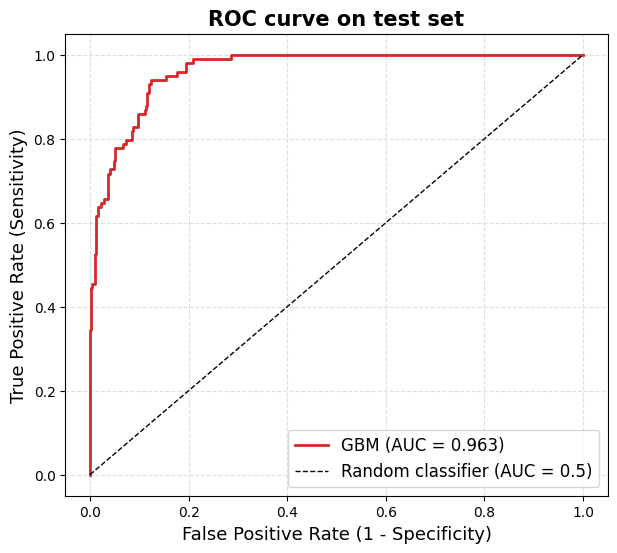

In [ ]:
fpr, tpr, _ = roc_curve(y_test_split, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#d62728', lw=2, label=f'GBM (AUC = {roc_auc_score(y_test_split, y_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.title('ROC curve on test set', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, ls='--', alpha=0.4)
plt.show()

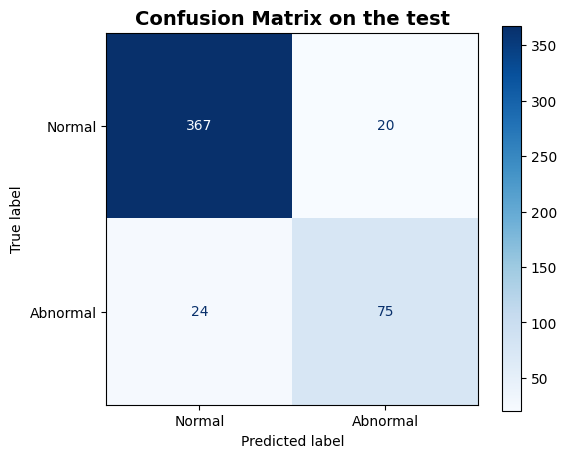

Correct Normal:367 из 387
Correct Abnormal:75 из 99
Missed patients (FN):24
False alarm (FP):20


In [ ]:
cm = confusion_matrix(y_test_split, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix on the test', fontsize=14, fontweight='bold')
plt.show()

print(f"Correct Normal:{cm[0,0]} из {cm[0].sum()}")
print(f"Correct Abnormal:{cm[1,1]} из {cm[1].sum()}")
print(f"Missed patients (FN):{cm[1,0]}")
print(f"False alarm (FP):{cm[0,1]}")

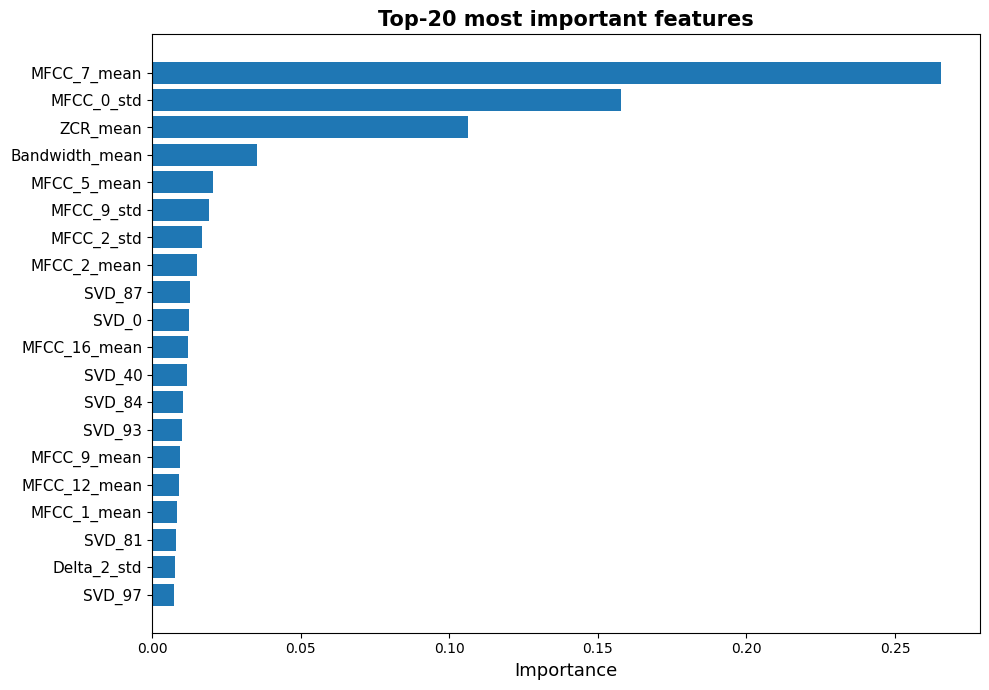

In [ ]:
feature_names = (
    [f'MFCC_{i}_mean' for i in range(20)] + [f'MFCC_{i}_std' for i in range(20)] +
    [f'Delta_{i}_mean' for i in range(20)] + [f'Delta_{i}_std' for i in range(20)] +
    ['Centroid_mean', 'Centroid_std', 'Bandwidth_mean', 'Bandwidth_std',
     'Rolloff_mean', 'Rolloff_std', 'ZCR_mean', 'ZCR_std'] +
    [f'SVD_{i}' for i in range(100)]
)

importances = gbm_weighted.feature_importances_
top20_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 7))
plt.barh(range(20), importances[top20_idx], color='#1f77b4')
plt.yticks(range(20), [feature_names[i] for i in top20_idx], fontsize=11)
plt.xlabel('Importance', fontsize=13)
plt.title('Top-20 most important features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

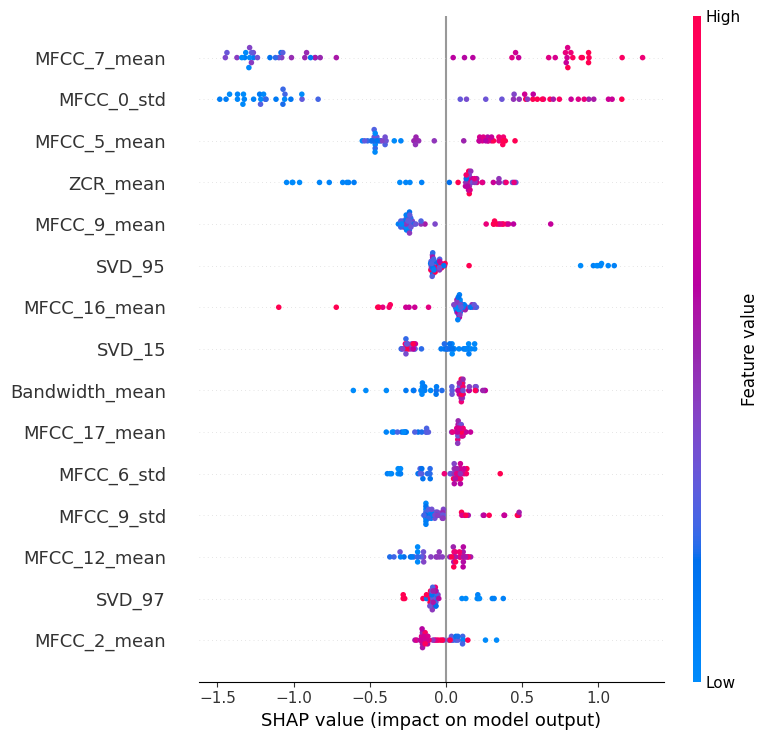

In [ ]:
explainer = shap.TreeExplainer(gbm_weighted)
shap_values = explainer.shap_values(X_te[:50])

feature_names = (
    [f'MFCC_{i}_mean' for i in range(20)] + [f'MFCC_{i}_std' for i in range(20)] +
    [f'Delta_{i}_mean' for i in range(20)] + [f'Delta_{i}_std' for i in range(20)] +
    ['Centroid_mean', 'Centroid_std', 'Bandwidth_mean', 'Bandwidth_std',
     'Rolloff_mean', 'Rolloff_std', 'ZCR_mean', 'ZCR_std'] +
    [f'SVD_{i}' for i in range(100)]
)

shap.summary_plot(shap_values, X_te[:50], feature_names=feature_names, max_display=15)